# Tutorial 4: Diagnostics — SBC, Coverage, and Posterior Predictive Checks

**Course:** AI4Science — Simulation-Based Inference\
**Lecture link:** Lecture II, Part II (Diagnostics and Validation)

---

### Learning objectives
- Run SBC and interpret rank histograms
- See what failed diagnostics look like
- Understand: **necessary but not sufficient**

> **Runtime:** Select **GPU** in Colab


In [ ]:
!pip install -q sbi torch matplotlib

import torch, numpy as np, matplotlib.pyplot as plt
from sbi.utils import BoxUniform
from sbi.inference import NPE, simulate_for_sbi
from sbi.analysis import pairplot
from sbi.utils.user_input_checks import process_prior, process_simulator, check_sbi_inputs

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 460.0/460.0 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 768.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 114.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:0

## 1. Train a Good Model

In [ ]:
num_dim = 2
prior = BoxUniform(low=-2*torch.ones(num_dim), high=2*torch.ones(num_dim))
def simulator(theta): return theta + 0.3 * torch.randn_like(theta)

prior, _, prn = process_prior(prior)
sim_fn = process_simulator(simulator, prior, prn)
check_sbi_inputs(sim_fn, prior)

theta_train, x_train = simulate_for_sbi(sim_fn, prior, num_simulations=10_000)
inference = NPE(prior, density_estimator="nsf")
inference.append_simulations(theta_train, x_train)
inference.train(show_train_summary=False)
posterior = inference.build_posterior()
print("✓ Well-trained NPE ready")


  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 104 epochs.✓ Well-trained NPE ready


## 2. Posterior Predictive Check

  0%|          | 0/500 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/nflows/transforms/lu.py:80: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at ../aten/src/ATen/native/BatchLinearAlgebra.cpp:2190.)
  outputs, _ = torch.triangular_solve(


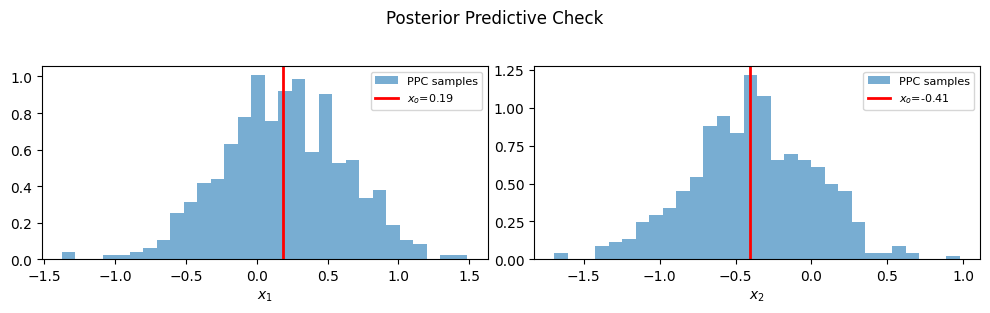

✓ PPC passed: x_o is within the distribution of simulated data


In [ ]:
theta_true = torch.tensor([0.5, -0.8])
x_o = simulator(theta_true.unsqueeze(0)).squeeze()

post_samples = posterior.sample((500,), x=x_o)
x_ppc = torch.stack([simulator(t.unsqueeze(0)).squeeze() for t in post_samples])

fig, axes = plt.subplots(1, num_dim, figsize=(10, 3))
for d in range(num_dim):
    axes[d].hist(x_ppc[:, d].numpy(), bins=30, alpha=0.6, density=True, label="PPC samples")
    axes[d].axvline(x_o[d].item(), color="red", lw=2, label=f"$x_o$={x_o[d]:.2f}")
    axes[d].set_xlabel(f"$x_{d+1}$"); axes[d].legend(fontsize=8)
plt.suptitle("Posterior Predictive Check", y=1.03)
plt.tight_layout(); plt.show()
print("✓ PPC passed: x_o is within the distribution of simulated data")


## 3. Simulation-Based Calibration (SBC)

For each of $L$ calibration samples: draw true $\theta_i$, simulate $x_i$, get posterior,
and rank the true parameter among posterior samples. Ranks should be **uniform**.


In [ ]:
from sbi.diagnostics import run_sbc, check_sbc

num_sbc = 500
thetas_cal = prior.sample((num_sbc,))
xs_cal = torch.stack([sim_fn(t.unsqueeze(0)).squeeze() for t in thetas_cal])

print(f"Running SBC with {num_sbc} calibration samples (takes a few minutes)...")
ranks, dap = run_sbc(thetas_cal, xs_cal, posterior, num_posterior_samples=1000)
print("✓ SBC complete!")


Running SBC with 500 calibration samples (takes a few minutes)...


/usr/local/lib/python3.12/dist-packages/sbi/utils/diagnostics_utils.py:45: UserWarning: Capping max_sampling_batch_size from 10000 to 200 to avoid excessive memory usage.
  posterior_samples = posterior.sample_batched(


Drawing 1000 samples for 500 observations:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating ranks for 500 SBC samples:   0%|          | 0/500 [00:00<?, ?it/s]

✓ SBC complete!


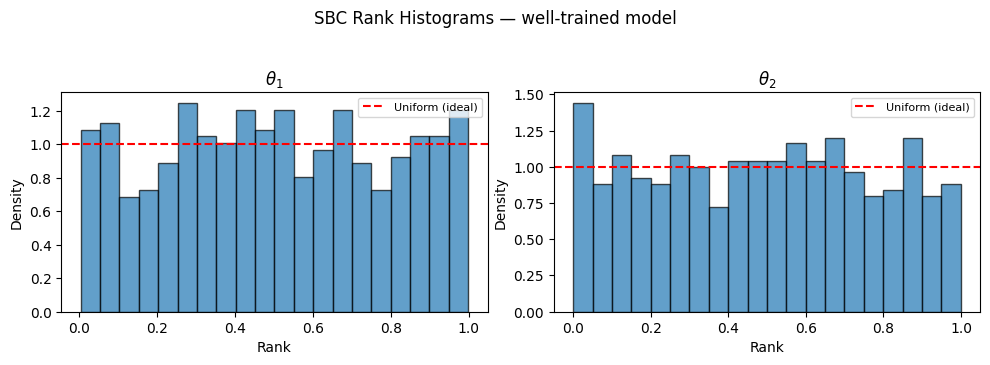

{'ks_pvals': tensor([0.6352, 0.6730]),
 'c2st_ranks': tensor([0.5020, 0.5080], dtype=torch.float64),
 'c2st_dap': tensor([0.5020, 0.4990], dtype=torch.float64)}

In [ ]:
fig, axes = plt.subplots(1, num_dim, figsize=(10, 3.5))
for d in range(num_dim):
    axes[d].hist(ranks[:, d].numpy()/1000, bins=20, density=True, alpha=0.7, edgecolor="black", lw=0.5)
    axes[d].axhline(1.0, color="red", ls="--", lw=1.5, label="Uniform (ideal)")
    axes[d].set_xlabel("Rank"); axes[d].set_ylabel("Density")
    axes[d].set_title(f"$\\theta_{d+1}$"); axes[d].legend(fontsize=8)
plt.suptitle("SBC Rank Histograms — well-trained model", y=1.03)
plt.tight_layout(); plt.show()
check_sbc(ranks, thetas_cal, dap, num_posterior_samples=1000)


## 4. Bad Model for Comparison

In [ ]:
theta_bad, x_bad = simulate_for_sbi(sim_fn, prior, num_simulations=50)
inf_bad = NPE(prior, density_estimator="mdn")
inf_bad.append_simulations(theta_bad, x_bad)
inf_bad.train(show_train_summary=False)
post_bad = inf_bad.build_posterior()

ranks_bad, dap_bad = run_sbc(thetas_cal, xs_cal, post_bad, num_posterior_samples=1000)

  0%|          | 0/50 [00:00<?, ?it/s]

 Neural network successfully converged after 133 epochs.

/usr/local/lib/python3.12/dist-packages/sbi/utils/diagnostics_utils.py:45: UserWarning: Capping max_sampling_batch_size from 10000 to 200 to avoid excessive memory usage.
  posterior_samples = posterior.sample_batched(


Drawing 1000 samples for 500 observations:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating ranks for 500 SBC samples:   0%|          | 0/500 [00:00<?, ?it/s]

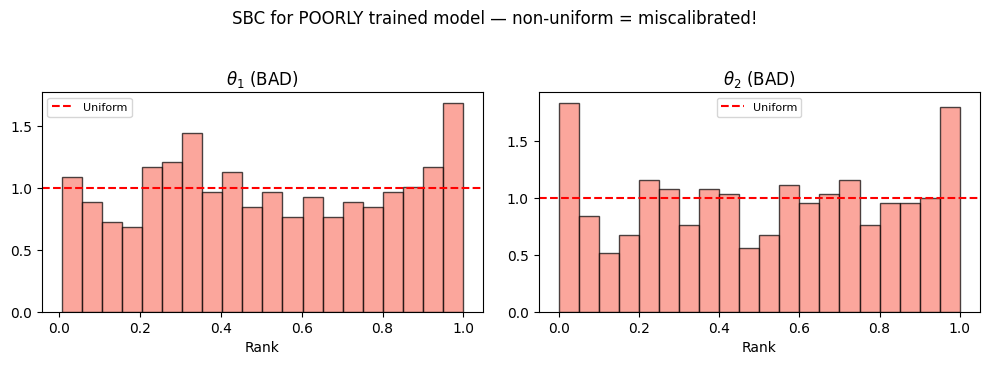

⚠ Non-uniform histograms reveal miscalibration!


In [ ]:
fig, axes = plt.subplots(1, num_dim, figsize=(10, 3.5))
for d in range(num_dim):
    axes[d].hist(ranks_bad[:, d].numpy()/1000, bins=20, density=True, alpha=0.7,
                 color="salmon", edgecolor="black", lw=0.5)
    axes[d].axhline(1.0, color="red", ls="--", lw=1.5, label="Uniform")
    axes[d].set_xlabel("Rank"); axes[d].set_title(f"$\\theta_{d+1}$ (BAD)")
    axes[d].legend(fontsize=8)
plt.suptitle("SBC for POORLY trained model — non-uniform = miscalibrated!", y=1.03)
plt.tight_layout(); plt.show()
print("⚠ Non-uniform histograms reveal miscalibration!")

## 5. Exercises

**Exercise 1:** Train with 500, 2000, 5000, and 20000 sims. At what point does SBC become acceptable?

**Exercise 2:** A posterior equal to the prior passes SBC perfectly. Why is it useless?


<details>
<summary><b>▶ Solution — Exercise 1: SBC vs simulation budget</b></summary>

As the simulation budget increases, the SBC rank histograms become more uniform. There is typically a threshold (problem-dependent) below which the network is undertrained. For this simple 2D Gaussian, ~2000 sims usually suffice.
</details>

  0%|          | 0/500 [00:00<?, ?it/s]

 Neural network successfully converged after 109 epochs.

/usr/local/lib/python3.12/dist-packages/sbi/utils/diagnostics_utils.py:45: UserWarning: Capping max_sampling_batch_size from 10000 to 500 to avoid excessive memory usage.
  posterior_samples = posterior.sample_batched(


Drawing 500 samples for 200 observations:   0%|          | 0/500 [00:00<?, ?it/s]

Calculating ranks for 200 SBC samples:   0%|          | 0/200 [00:00<?, ?it/s]

...

Calculating ranks for 200 SBC samples:   0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/20000 [00:00<?, ?it/s]

 Neural network successfully converged after 85 epochs.

Drawing 500 samples for 200 observations:   0%|          | 0/500 [00:00<?, ?it/s]

Calculating ranks for 200 SBC samples:   0%|          | 0/200 [00:00<?, ?it/s]

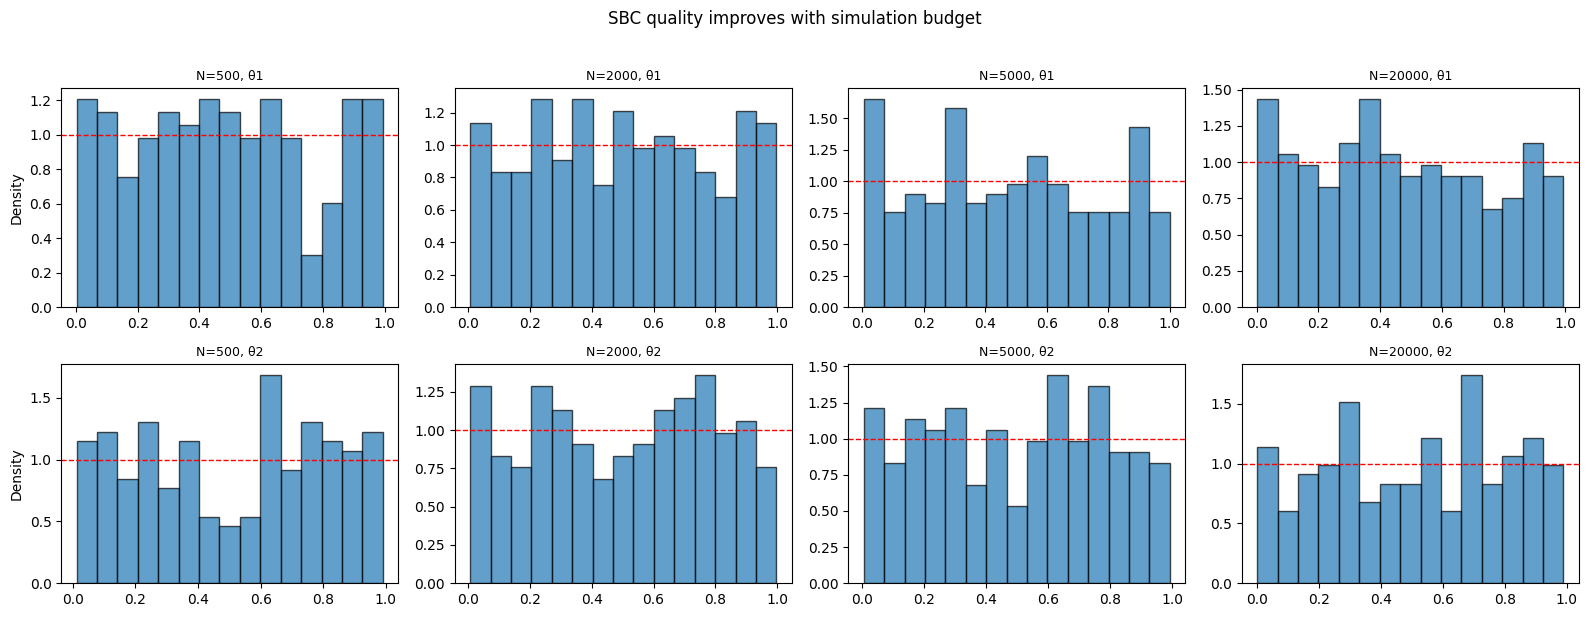

In [ ]:
# === SOLUTION: Exercise 1 — SBC vs simulation budget ===
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for col, n_sim in enumerate([500, 2000, 5000, 20000]):
    t, x = simulate_for_sbi(sim_fn, prior, num_simulations=n_sim)
    inf = NPE(prior, density_estimator="nsf")
    inf.append_simulations(t, x)
    inf.train(show_train_summary=False)
    post = inf.build_posterior()

    r, _ = run_sbc(thetas_cal[:200], xs_cal[:200], post, num_posterior_samples=500)

    for d in range(num_dim):
        ax = axes[d][col]
        ax.hist(r[:, d].numpy()/500, bins=15, density=True, alpha=0.7, edgecolor="black", lw=0.5)
        ax.axhline(1.0, color="red", ls="--", lw=1)
        ax.set_title(f"N={n_sim}, θ{d+1}", fontsize=9)
        if col == 0: ax.set_ylabel("Density")

plt.suptitle("SBC quality improves with simulation budget", y=1.02)
plt.tight_layout(); plt.show()


<details>
<summary><b>▶ Solution — Exercise 2: Prior as posterior</b></summary>

If $q(\theta|x) = p(\theta)$ (the prior), then for any true $\theta_i$, its rank among prior samples is uniform by definition. SBC passes perfectly! But this posterior is completely uninformative — it ignores the data entirely. This shows that **SBC checks calibration, not precision**. A useless-but-calibrated posterior is still useless.
</details>

Calculating ranks for 200 SBC samples:   0%|          | 0/200 [00:00<?, ?it/s]

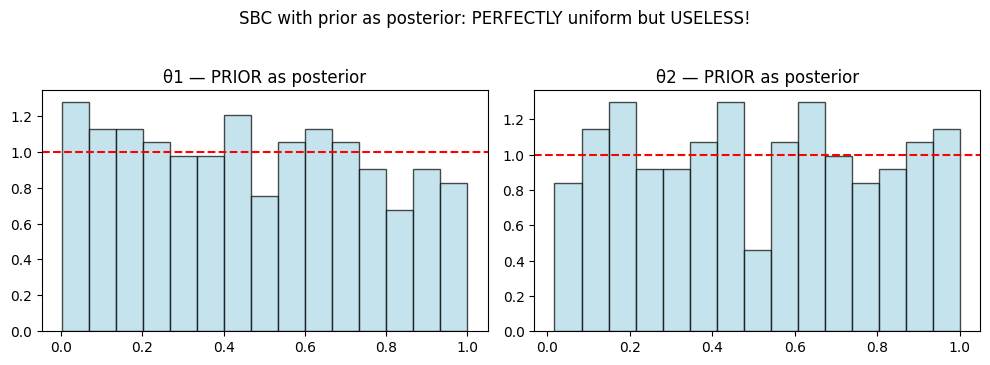

The prior passes SBC perfectly because it's calibrated by construction.
But it provides ZERO information about the parameters → useless for science!

⇒ Coverage is NECESSARY but NOT SUFFICIENT for a good posterior.


In [ ]:
# === SOLUTION: Exercise 2 — Prior as "posterior" ===
# The prior ignores data entirely, but is perfectly calibrated

class PriorAsPosterior:
    def sample(self, shape, x=None):
        return prior.sample(shape)  # ignores x entirely!
    def sample_batched(self, shape, x=None, show_progress_bars = False):

        return prior.sample((shape[0], x.shape[0]))  # ignores x entirely!

prior_post = PriorAsPosterior()
ranks_prior, _ = run_sbc(thetas_cal[:200], xs_cal[:200], prior_post, num_posterior_samples=500)

fig, axes = plt.subplots(1, num_dim, figsize=(10, 3.5))
for d in range(num_dim):
    axes[d].hist(ranks_prior[:, d].numpy()/500, bins=15, density=True, alpha=0.7,
                 color="lightblue", edgecolor="black", lw=0.5)
    axes[d].axhline(1.0, color="red", ls="--", lw=1.5)
    axes[d].set_title(f"θ{d+1} — PRIOR as posterior")
plt.suptitle("SBC with prior as posterior: PERFECTLY uniform but USELESS!", y=1.03)
plt.tight_layout(); plt.show()
print("The prior passes SBC perfectly because it's calibrated by construction.")
print("But it provides ZERO information about the parameters → useless for science!")
print("\n⇒ Coverage is NECESSARY but NOT SUFFICIENT for a good posterior.")


---

**Congratulations!** You've completed the full SBI tutorial series:
1. NPE basics and amortisation
2. NPE vs NLE vs NRE comparison
3. Sequential inference (SNPE-C)
4. Diagnostics (PPC, SBC) and their limitations

You now have hands-on experience with the full SBI workflow.
